# Smart Manufacturing Predictive Maintenance System
## Classification Track — Review 1, Part A

### Objective

Predict **Machine failure** (binary: 0 = no failure, 1 = failure) from machine operating characteristics.

This notebook covers the five Part A algorithms required for Review 1: Logistic Regression, K-Nearest Neighbors, Gaussian Naive Bayes, Decision Tree Classifier, and Support Vector Machine (SVC).

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Display settings
pd.set_option("display.max_columns", None)

# Visualization style
sns.set_theme(style="whitegrid")

# Reproducibility
RANDOM_STATE = 42


In [2]:
# Load dataset

file_path = "../Datasets/ai4i2020.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())


Dataset loaded successfully!
Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. Classification Target and Leakage-Safe Feature Selection

The classification target is **Machine failure** (binary).

The failure-mode flags **TWF, HDF, PWF, OSF, RNF** are indicators of *which* failure mechanism occurred — they are only populated once a failure has already happened, so including them as predictors would leak the outcome directly into the model. They are excluded here for the same reason `Machine failure` itself was excluded as a regression predictor.

**UDI** and **Product ID** are identifiers with no physical meaning and are excluded as well.

Unlike the regression track, **Tool wear [min]** is a legitimate predictor here — it is an independent operating characteristic, not derived from the failure outcome, so it is retained as a feature.

As in the regression notebook, the engineered feature **Temperature Difference [K]** (Process temperature − Air temperature) is carried over, since it represents thermal operating conditions more directly than either absolute temperature alone.


In [3]:
# Create a copy of the original dataset
classification_df = df.copy()

# Feature engineering (same as regression track)
classification_df["Temperature Difference [K]"] = (
    classification_df["Process temperature [K]"]
    - classification_df["Air temperature [K]"]
)

# Define target variable
target = "Machine failure"

# Columns that must not be used as classification predictors
columns_to_drop = [
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
    target
]

# Create feature matrix and target vector
X = classification_df.drop(columns=columns_to_drop)
y = classification_df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used for classification:")
display(X.head())


Feature matrix shape: (10000, 7)
Target shape: (10000,)

Features used for classification:


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature Difference [K]
0,M,298.1,308.6,1551,42.8,0,10.5
1,L,298.2,308.7,1408,46.3,3,10.5
2,L,298.1,308.5,1498,49.4,5,10.4
3,L,298.2,308.6,1433,39.5,7,10.4
4,L,298.2,308.7,1408,40.0,9,10.5


In [4]:
# Target class distribution

failure_counts = y.value_counts()
failure_percentages = y.value_counts(normalize=True) * 100

failure_summary = pd.DataFrame({
    "Count": failure_counts,
    "Percentage": failure_percentages.round(2)
})

print("Machine Failure Class Distribution:")
display(failure_summary)


Machine Failure Class Distribution:


,Count,Percentage
Machine failure,,
0,9661,96.61
1,339,3.39


### Observation

As already noted in the regression notebook's EDA, Machine failure is heavily imbalanced (~3.4% failures vs ~96.6% no-failure). This split is stratified on the target to preserve this ratio in both the training and test sets, and it means Accuracy alone will be a misleading metric — weighted F1, precision, and recall are tracked alongside it for every model.


## 2. Train-Test Split

An 80:20 split is used, stratified directly on the binary target (unlike the regression track, no quantile binning is needed here since the target is already categorical).


In [5]:
# Perform an 80:20 stratified train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (8000, 7)
Testing set shape: (2000, 7)


In [6]:
# Confirm class balance is preserved across the split

split_balance = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Samples": [len(y_train), len(y_test)],
    "Failure Count": [y_train.sum(), y_test.sum()],
    "Failure Percentage": [
        (y_train.sum() / len(y_train)) * 100,
        (y_test.sum() / len(y_test)) * 100
    ]
})

display(split_balance.round(2))


,Dataset,Samples,Failure Count,Failure Percentage
0,Training,8000,271,3.39
1,Testing,2000,68,3.40


## 3. Preprocessing Pipeline

The same leakage-safe approach as the regression track is used: numerical features are scaled and the categorical `Type` feature is one-hot encoded, both wrapped inside a `ColumnTransformer` inside a `Pipeline` so that fitting happens only on the training fold in every case (including inside cross-validation, in Review 2).


In [7]:
# Identify numerical and categorical features

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]"
]

categorical_features = [
    "Type"
]

# Preprocessing for numerical features
numerical_transformer = StandardScaler()

# Preprocessing for categorical features
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")


Preprocessing pipeline created successfully.


## 4. Classification Models — Review 1, Part A

The following five algorithms are implemented to predict **Machine failure**:

1. Logistic Regression
2. K-Nearest Neighbors Classifier
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine (SVC)

Each model uses the same training/testing split and preprocessing pipeline, trained with baseline (default) hyperparameters. Accuracy, weighted Precision, weighted Recall, weighted F1-score, and a confusion matrix are reported for every model, matching the Review 1 Part A rubric requirement. Hyperparameter tuning is deferred to Review 2, in line with the two-phase baseline-then-tune approach used in the regression track.


### 4.1 Logistic Regression

Logistic Regression is the baseline classifier. It models the log-odds of machine failure as a linear function of the input features.


Logistic Regression Results
------------------------------
Accuracy  : 0.9670
Precision : 0.9562
Recall    : 0.9670
F1-Score  : 0.9557


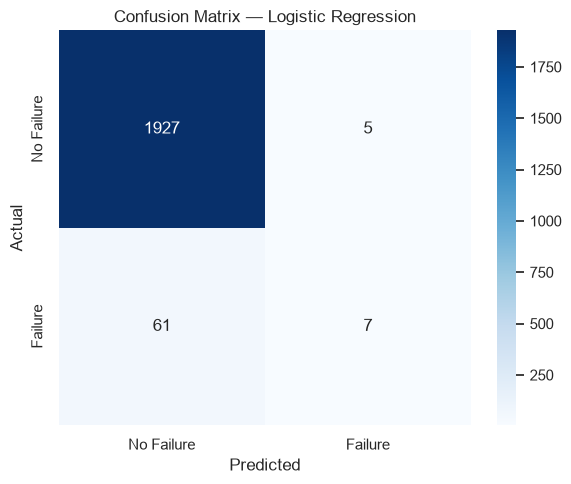

In [8]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression pipeline
logistic_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

# Train the model
logistic_regression.fit(X_train, y_train)

# Generate predictions
y_pred_logistic = logistic_regression.predict(X_test)

# Calculate evaluation metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic, average="weighted", zero_division=0)
logistic_recall = recall_score(y_test, y_pred_logistic, average="weighted", zero_division=0)
logistic_f1 = f1_score(y_test, y_pred_logistic, average="weighted", zero_division=0)
logistic_cm = confusion_matrix(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("-" * 30)
print(f"Accuracy  : {logistic_accuracy:.4f}")
print(f"Precision : {logistic_precision:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"F1-Score  : {logistic_f1:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### 4.2 K-Nearest Neighbors Classifier

KNN classifies a sample based on the majority class among its nearest neighbors in the scaled feature space.


KNN Classifier Results
------------------------------
Accuracy  : 0.9755
Precision : 0.9734
Recall    : 0.9755
F1-Score  : 0.9700


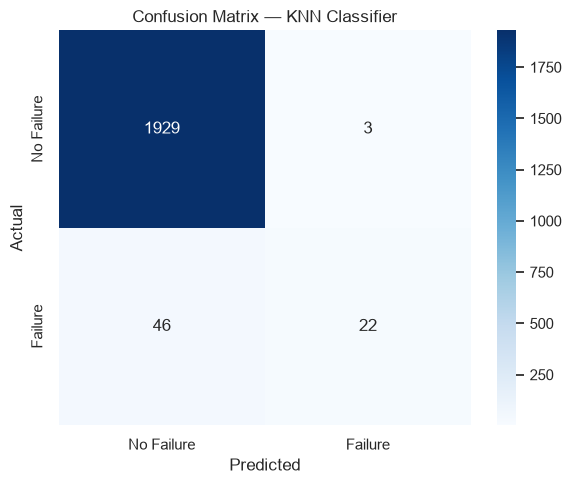

In [9]:
from sklearn.neighbors import KNeighborsClassifier

# KNN Classifier pipeline
knn_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

# Train the model
knn_classifier.fit(X_train, y_train)

# Generate predictions
y_pred_knn = knn_classifier.predict(X_test)

# Calculate evaluation metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average="weighted", zero_division=0)
knn_recall = recall_score(y_test, y_pred_knn, average="weighted", zero_division=0)
knn_f1 = f1_score(y_test, y_pred_knn, average="weighted", zero_division=0)
knn_cm = confusion_matrix(y_test, y_pred_knn)

print("KNN Classifier Results")
print("-" * 30)
print(f"Accuracy  : {knn_accuracy:.4f}")
print(f"Precision : {knn_precision:.4f}")
print(f"Recall    : {knn_recall:.4f}")
print(f"F1-Score  : {knn_f1:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)
plt.title("Confusion Matrix — KNN Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### 4.3 Gaussian Naive Bayes

Gaussian Naive Bayes assumes conditional independence between features given the class, and models each numerical feature as normally distributed within each class.


Gaussian Naive Bayes Results
------------------------------
Accuracy  : 0.9605
Precision : 0.9509
Recall    : 0.9605
F1-Score  : 0.9548


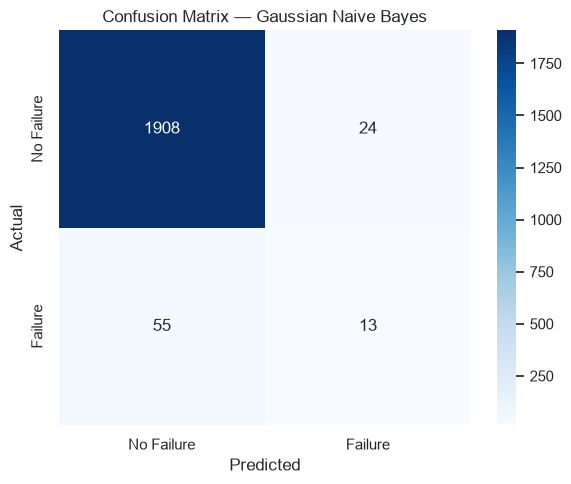

In [10]:
from sklearn.naive_bayes import GaussianNB

# Gaussian Naive Bayes pipeline
gaussian_nb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])

# Train the model
gaussian_nb.fit(X_train, y_train)

# Generate predictions
y_pred_nb = gaussian_nb.predict(X_test)

# Calculate evaluation metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average="weighted", zero_division=0)
nb_recall = recall_score(y_test, y_pred_nb, average="weighted", zero_division=0)
nb_f1 = f1_score(y_test, y_pred_nb, average="weighted", zero_division=0)
nb_cm = confusion_matrix(y_test, y_pred_nb)

print("Gaussian Naive Bayes Results")
print("-" * 30)
print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1-Score  : {nb_f1:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)
plt.title("Confusion Matrix — Gaussian Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### 4.4 Decision Tree Classifier

Decision Tree Classification recursively splits the feature space to separate the two classes, using default splitting criteria at the baseline stage.


Decision Tree Classifier Results
------------------------------
Accuracy  : 0.9825
Precision : 0.9829
Recall    : 0.9825
F1-Score  : 0.9827


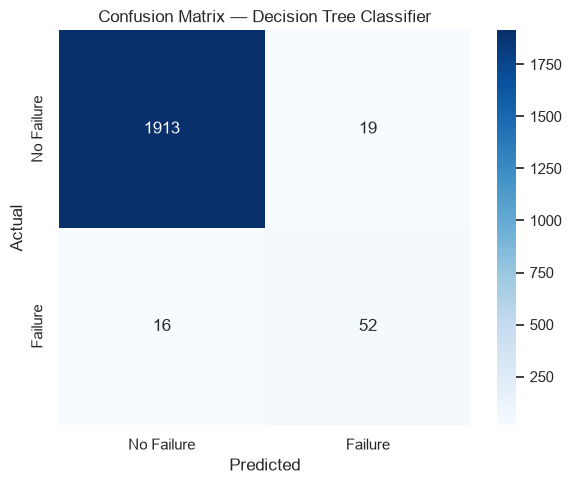

In [11]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree Classifier pipeline
decision_tree_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ))
])

# Train the model
decision_tree_classifier.fit(X_train, y_train)

# Generate predictions
y_pred_tree_clf = decision_tree_classifier.predict(X_test)

# Calculate evaluation metrics
tree_clf_accuracy = accuracy_score(y_test, y_pred_tree_clf)
tree_clf_precision = precision_score(y_test, y_pred_tree_clf, average="weighted", zero_division=0)
tree_clf_recall = recall_score(y_test, y_pred_tree_clf, average="weighted", zero_division=0)
tree_clf_f1 = f1_score(y_test, y_pred_tree_clf, average="weighted", zero_division=0)
tree_clf_cm = confusion_matrix(y_test, y_pred_tree_clf)

print("Decision Tree Classifier Results")
print("-" * 30)
print(f"Accuracy  : {tree_clf_accuracy:.4f}")
print(f"Precision : {tree_clf_precision:.4f}")
print(f"Recall    : {tree_clf_recall:.4f}")
print(f"F1-Score  : {tree_clf_f1:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(
    tree_clf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)
plt.title("Confusion Matrix — Decision Tree Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### 4.5 Support Vector Machine (SVC)

SVC finds a decision boundary that best separates the two classes, using a default RBF kernel at the baseline stage. Features are scaled via the shared preprocessing pipeline, which is required for distance-based methods like SVC.


SVC Results
------------------------------
Accuracy  : 0.9745
Precision : 0.9728
Recall    : 0.9745
F1-Score  : 0.9679


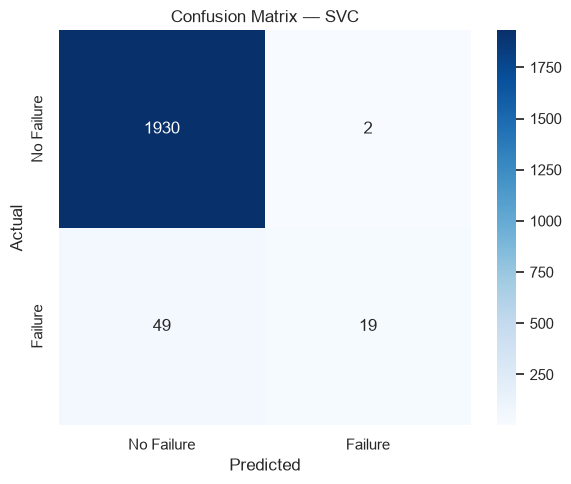

In [12]:
from sklearn.svm import SVC

# SVC pipeline
svc_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(random_state=RANDOM_STATE))
])

# Train the model
svc_classifier.fit(X_train, y_train)

# Generate predictions
y_pred_svc = svc_classifier.predict(X_test)

# Calculate evaluation metrics
svc_accuracy = accuracy_score(y_test, y_pred_svc)
svc_precision = precision_score(y_test, y_pred_svc, average="weighted", zero_division=0)
svc_recall = recall_score(y_test, y_pred_svc, average="weighted", zero_division=0)
svc_f1 = f1_score(y_test, y_pred_svc, average="weighted", zero_division=0)
svc_cm = confusion_matrix(y_test, y_pred_svc)

print("SVC Results")
print("-" * 30)
print(f"Accuracy  : {svc_accuracy:.4f}")
print(f"Precision : {svc_precision:.4f}")
print(f"Recall    : {svc_recall:.4f}")
print(f"F1-Score  : {svc_f1:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(
    svc_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)
plt.title("Confusion Matrix — SVC")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### 4.6 Preliminary Model Comparison

The five Part A models are compared using Accuracy, Precision, Recall, and weighted F1-score. Given the ~3.4% failure rate, models are ranked by **F1-score** rather than Accuracy, since a model that simply predicts "no failure" for everything would score ~96.6% accuracy while being useless in practice.


In [13]:
# Create the preliminary classification comparison table

classification_results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1-Score": logistic_f1
    },
    {
        "Model": "KNN Classifier",
        "Accuracy": knn_accuracy,
        "Precision": knn_precision,
        "Recall": knn_recall,
        "F1-Score": knn_f1
    },
    {
        "Model": "Gaussian Naive Bayes",
        "Accuracy": nb_accuracy,
        "Precision": nb_precision,
        "Recall": nb_recall,
        "F1-Score": nb_f1
    },
    {
        "Model": "Decision Tree Classifier",
        "Accuracy": tree_clf_accuracy,
        "Precision": tree_clf_precision,
        "Recall": tree_clf_recall,
        "F1-Score": tree_clf_f1
    },
    {
        "Model": "SVC",
        "Accuracy": svc_accuracy,
        "Precision": svc_precision,
        "Recall": svc_recall,
        "F1-Score": svc_f1
    }
])

# Rank models by weighted F1-score
classification_results_df = (
    classification_results_df
    .sort_values(by="F1-Score", ascending=False)
    .reset_index(drop=True)
)

# Add ranking
classification_results_df.insert(
    0,
    "Rank",
    range(1, len(classification_results_df) + 1)
)

display(classification_results_df.round(4))


,Rank,Model,Accuracy,Precision,Recall,F1-Score
0,1,Decision Tree Classifier,0.9825,0.9829,0.9825,0.9827
1,2,KNN Classifier,0.9755,0.9734,0.9755,0.9700
2,3,SVC,0.9745,0.9728,0.9745,0.9679
3,4,Logistic Regression,0.9670,0.9562,0.9670,0.9557
4,5,Gaussian Naive Bayes,0.9605,0.9509,0.9605,0.9548
